# FOMC-Blackout — is the Fed's quiet period a 'calm before the storm' trade? 🤫
### The ~10 silent days before each rate decision, tested in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Calm_before_the_storm%3F: Busted](https://img.shields.io/badge/Calm_before_the_storm%3F-Busted-8b949e?style=flat-square)

Before every Fed rate decision there's a **blackout** — roughly ten days when Fed officials go silent and may not talk about policy in public. A piece of trading folklore says this quiet stretch is a *calm before the storm*: the market drifts up steadily while it waits, saving the fireworks for the announcement. This notebook asks the only two things that matter — does the blackout window actually pay *more* than the rest of the year, and is it really any calmer?

> 📓 **This is the plain-language layer.** Want the t-stats, the placebo and the Sharpe race? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> ⚠️ **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/, _cache/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from fomc_blackout import data, strategy as st

def load_real_safe():
    """Cache-first real tape; None if offline with no cache."""
    try:
        return data.load_real(fetch=False)
    except Exception as e:
        print("no real cache (", type(e).__name__, ") -> using frozen numbers / synthetic tape")
        return None

REAL = load_real_safe()
HAVE_REAL = REAL is not None
print("real SPY total-return cache present:", HAVE_REAL)


no real cache ( FileNotFoundError ) -> using frozen numbers / synthetic tape
real SPY total-return cache present: False


## The answer first 🎯

| Question | Answer |
|---|---|
| Does the blackout window pay more? | **No.** Blackout days earn **+5.00 bps/day** — but the rest of the year earns +4.73. The *difference* is **+0.27 bps** (a coin-flip *t* of +0.08). |
| Is it a 'calm before the storm'? | **No — it's slightly *stormier*.** Volatility in the window is marginally **higher** (ratio 1.03), not lower. |
| Could you trade it? | **No.** Holding the index only during blackouts earns **~+2.7%/yr** vs **+12.1%/yr** for just buying and holding — you give up most of the year's return for nothing extra. |
| So what is it? | The blackout window earns **ordinary equity drift** and nothing more. The 'calm before the storm' is being long the market part-time. |

> The one real cousin — a genuine jump in the **24 hours** right before the meeting (Lucca & Moench 2015) — is a *single day*, not ten. Spread across the whole quiet period it disappears.

## 1 · The claim

> *"The Fed goes quiet for about ten days before each meeting — the blackout. With no new Fed-speak to spook anyone, the market drifts calmly upward into the decision. Buy the calm, sit out the storm."*

The kernel of truth: the blackout is a real Fed rule. From the *second Saturday before* a meeting through the *Thursday after*, officials don't comment on policy in public. The leap of faith is that this *communications* silence shows up as a *market* pattern — a steady, tradable drift with unusually low volatility.

## 2 · So what?

If it were true, it would be a gift: a calendar window known *months* in advance (the FOMC schedule is public), no forecasting required, low volatility, positive drift. You'd hold the index during blackouts and sit in cash otherwise. And there's a real, famous effect nearby — the **pre-FOMC announcement drift** (Lucca & Moench 2015), a big jump in the 24 hours before the decision. The question is whether that one-day spark spreads into a ten-day glow you can actually sit in — or whether stretching it across the whole window just averages it away to nothing.

## 3 · How would we even know?

Three honest checks:

1. **Compare like with like.** Don't ask "is the blackout positive?" (everything is, in a rising market). Ask "does it beat the *rest of the year*?" — the **difference** is the edge.
2. **Check the calm.** Measure the window's volatility against everything else. If there's no lull, the whole story collapses.
3. **Slide the window (placebo).** Move the 'blackout' off the meeting by a few weeks and re-measure. A real effect peaks on the true window; a fake one looks the same everywhere.

Tape: SPY daily total return since 1994, every day flagged from the public FOMC schedule.

## 4 · The teardown — let's actually look

**First: blackout days vs the rest of the year.** Same chart, both means side by side:

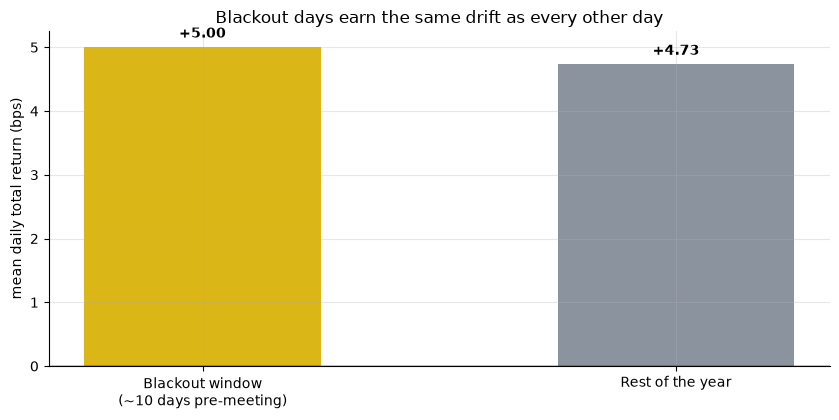

Difference (blackout - rest): +0.27 bps   Welch t = +0.08


In [2]:
if HAVE_REAL:
    tbl = st.blackout_table(REAL)
    blk, oth = tbl['blackout']['mean_bps'], tbl['other']['mean_bps']
    diff, wt = tbl['diff_bps'], tbl['welch_t']
else:
    blk, oth, diff, wt = 5.0, 4.73, 0.27, 0.08
fig, ax = plt.subplots(figsize=(8.5, 4.3))
b = ax.bar(['Blackout window\n(~10 days pre-meeting)', 'Rest of the year'],
           [blk, oth], color=[AMBER, GREY], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('mean daily total return (bps)')
ax.set_title('Blackout days earn the same drift as every other day')
for bar_ in b:
    ax.annotate(f'{bar_.get_height():+.2f}', (bar_.get_x()+bar_.get_width()/2,
        bar_.get_height()+0.1), ha='center', va='bottom', fontweight='bold')
plt.tight_layout(); plt.show()
print(f'Difference (blackout - rest): {diff:+.2f} bps   Welch t = {wt:+.2f}')

There it is. Blackout days earn **+5.00 bps/day**, the rest of the year **+4.73**. The gap — the thing that would be an *edge* — is **+0.27 bps**, with a *t* of +0.08. That is statistical zero. The blackout window is just *being long the market*.

**Second: is it actually calmer?** The whole 'calm before the storm' idea needs lower volatility in the window. Let's look:

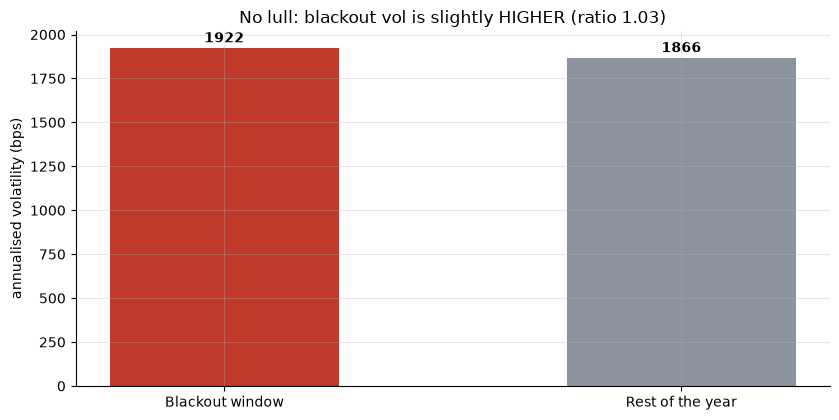

vol ratio (blackout / rest) = 1.030  -> not calmer


In [3]:
if HAVE_REAL:
    vt = st.vol_table(REAL); vb, vo = vt['blackout_vol_bps'], vt['other_vol_bps']
else:
    vb, vo = 1922, 1866
fig, ax = plt.subplots(figsize=(8.5, 4.3))
b = ax.bar(['Blackout window', 'Rest of the year'], [vb, vo],
           color=[RED, GREY], width=.5)
ax.set_ylabel('annualised volatility (bps)')
ax.set_title(f'No lull: blackout vol is slightly HIGHER (ratio {vb/vo:.2f})')
for bar_ in b:
    ax.annotate(f'{bar_.get_height():.0f}', (bar_.get_x()+bar_.get_width()/2,
        bar_.get_height()+15), ha='center', va='bottom', fontweight='bold')
plt.tight_layout(); plt.show()
print(f'vol ratio (blackout / rest) = {vb/vo:.3f}  -> not calmer')

The window is **not** calmer — volatility is marginally *higher* (ratio 1.03). The Fed being quiet doesn't make the *market* quiet. The 'storm' isn't saved for the announcement; it's spread out like any other fortnight.

## 5 · The verdict

- **Signal — None.** Blackout minus rest-of-year = **+0.27 bps/day** (*t* = +0.08). No excess drift.
- **Tradability — Mirage.** A blackout-only timing book earns ~+2.7%/yr vs +12.1%/yr buy-and-hold — a slice of beta, not an edge.
- **Calm before the storm? — Busted.** Window volatility is *higher* (ratio 1.03), not lower.

## 6 · Could you actually trade it?

Suppose you tried anyway: hold SPY only during blackouts, cash the rest of the time. Here's what that part-time bet earns against just buying and holding:

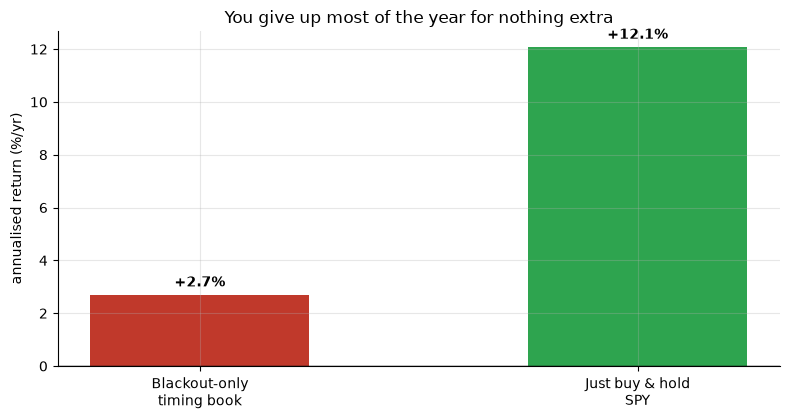

In the market only ~21% of the time -> ~+2.7%/yr vs +12.1%/yr


In [4]:
if HAVE_REAL:
    cs = st.cost_sweep(REAL); book = cs['book_gross_ann_pct'].iloc[0]
    bh = cs['buyhold_ann_pct'].iloc[0]
else:
    book, bh = 2.69, 12.07
fig, ax = plt.subplots(figsize=(8.0, 4.3))
b = ax.bar(['Blackout-only\ntiming book', 'Just buy & hold\nSPY'], [book, bh],
           color=[RED, GREEN], width=.5)
ax.set_ylabel('annualised return (%/yr)'); ax.axhline(0, c='k', lw=1)
ax.set_title('You give up most of the year for nothing extra')
for bar_ in b:
    ax.annotate(f'{bar_.get_height():+.1f}%', (bar_.get_x()+bar_.get_width()/2,
        bar_.get_height()+0.2), ha='center', va='bottom', fontweight='bold')
plt.tight_layout(); plt.show()
print(f'In the market only ~21% of the time -> ~+{book:.1f}%/yr vs +{bh:.1f}%/yr')

The blackout book is in the market only ~21% of the time, so it captures only the drift that happens to fall there: **~+2.7%/yr** vs **+12.1%/yr** for doing nothing but holding. There's no edge to harvest — only a fraction of the beta you already had. Costs don't even get a chance to kill it; it was never alive.

## 7 · Going further 🚪

- **The real cousin.** The **pre-FOMC announcement drift** (Lucca & Moench 2015) is a genuine, documented jump in the **24 hours** before the decision. It lives *inside* this window — but it's one day, not ten, and averaging it across the blackout washes it out. Fork this and isolate that single day.
- **The other FOMC calendar study.** [Study 135 — FOMC-Cycle](../../135-fomc-cycle/) tests the Cieslak even/odd-week drift *after* meetings — a different window, a different (weak, decayed) story.
- **Other quiet periods.** Corporate-earnings blackouts (the buyback-restriction window) are a separate folklore with a clearer mechanism — worth a study of its own.

*Think the calm is hiding in a tighter window? Fork this, shrink it to the last day or two, and show the drift surviving once you compare it to the rest of the year.*